# CAZyme family GH43 Analysis Workflow

Analysis of the Glycosly Hydrolase 43 family of CAZymes.

**Requirements:** `pip install tmap`

---
## Part A: From FASTA to TMAP

Load GH43 enzymes. Subset from dbCAN's full CAZyme dataset. 

### 1. Load sequences from FASTA

In [16]:
import numpy as np
from Bio import SeqIO

MAX_SEQS = 50_000

records = []
with open("./cazyme_data/GH43.fa") as f:
    for rec in SeqIO.parse(f, "fasta"):
        records.append(rec)
        if len(records) >= MAX_SEQS:
            break

ids_fasta = [rec.id for rec in records]
sequences = [str(rec.seq) for rec in records]

print(f"{len(sequences)} sequences loaded")
print(f"Length range: {min(len(s) for s in sequences)} -- {max(len(s) for s in sequences)} aa")
print(f"First ID:  {ids_fasta[0]}")
print(f"First seq: {sequences[0][:60]}...")


48078 sequences loaded
Length range: 40 -- 3224 aa
First ID:  ABK48312.1
First seq: MPAMRVTPKTALKRHLKMLNCALLGVLGTLGQVSAKQVSIHDPVMAKEAGQYYLFSTGPG...


### 2. Compute sequence properties

`sequence_properties` computes physicochemical descriptors from amino acid
sequences -- using BioPython protparams.

In [17]:
import numpy as np
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# AT PH 7.4, the following AAs are considered charged:
STANDARD_AAs = set("ACDEFGHIKLMNPQRSTVWY")
_HYDROPHOBIC = set("AVILMFYW")
_POLAR       = set("NQST")
_NEG_CHARGED     = set("DE")
_POS_CHARGED     = set("KRH")
_SPECIAL         = set("C")  # Cysteine can form disulfide bonds, affecting properties

PROP_KEYS = [
    "length", "molecular_weight", "isoelectric_point", "gravy",
    "charge_at_ph7", "aromaticity", "aliphatic_index",
    "frac_neg_charged", "frac_pos_charged", "frac_hydrophobic", "frac_polar", "n_cysteines",
]

def sequence_properties(records):
    n_invalid = 0
    rows = []
    for rec in records:
        seq = str(rec.seq).upper()
        row = {"id": rec.id.split("|")[0], **{k: np.nan for k in PROP_KEYS}}
        if seq and set(seq).issubset(STANDARD_AAs):
            try:
                pa = ProteinAnalysis(seq)
                aa = pa.get_amino_acids_percent()
                row["length"]            = len(seq)
                row["molecular_weight"]  = pa.molecular_weight()
                row["isoelectric_point"] = pa.isoelectric_point()
                row["gravy"]             = pa.gravy()
                row["charge_at_ph7"]     = pa.charge_at_pH(7.4)
                row["aromaticity"]       = pa.aromaticity()
                row["aliphatic_index"]   = (
                    aa.get("A", 0) + 2.9 * aa.get("V", 0) +
                    3.9 * (aa.get("I", 0) + aa.get("L", 0))
                ) * 100
                row["frac_neg_charged"]  = sum(aa.get(a, 0) for a in _NEG_CHARGED)
                row["frac_pos_charged"]  = sum(aa.get(a, 0) for a in _POS_CHARGED)
                row["frac_hydrophobic"]  = sum(aa.get(a, 0) for a in _HYDROPHOBIC)
                row["frac_polar"]        = sum(aa.get(a, 0) for a in _POLAR)
                row["n_cysteines"]       = seq.count("C")
            except Exception:
                n_invalid += 1
        else:
            n_invalid += 1
        rows.append(row)
    print(f"sequence_properties: {n_invalid}/{len(records)} sequences invalid (non-standard AAs or empty)")
    return pd.DataFrame(rows)

props_df = sequence_properties(records)

for col in PROP_KEYS:
    values = props_df[col]
    print(f"{col:25s}  min={np.nanmin(values):8.1f}  max={np.nanmax(values):10.1f}")


sequence_properties: 25/48078 sequences invalid (non-standard AAs or empty)
length                     min=    40.0  max=    3224.0
molecular_weight           min=  4446.7  max=  355351.3
isoelectric_point          min=     4.1  max=      11.9
gravy                      min=    -1.6  max=       0.6
charge_at_ph7              min=  -312.7  max=      57.4
aromaticity                min=     0.0  max=       0.2
aliphatic_index            min=    16.8  max=     123.1
frac_neg_charged           min=     0.0  max=       0.2
frac_pos_charged           min=     0.0  max=       0.3
frac_hydrophobic           min=     0.3  max=       0.5
frac_polar                 min=     0.1  max=       0.4
n_cysteines                min=     0.0  max=      45.0


---
## Part B: Pre-computed embeddings + annotations

For production protein TMAPs, we have:

1. **Embeddings** ESMC mean-pooled embeddings (.pt torch files)
2. **Annotation file** Custom cazyme annotation file as UniProt's auto-generated annotations are not accurate.

ESM-c embeddings can be generated with:
- `esm` Python package (Meta)
- ESM Metagenomic Atlas API
- Local inference with `fair-esm`

### 3. Load embeddings

This assumes pre-computed embeddings saved as .pt torch files.
The paths `./cazyme_data/GH43_esmc_300m.pt"` and `.cazyme_data/merged_cazyme_annotations.tsv` are dataset-specific --
replace them with your own.

In [18]:
import torch
import numpy as np
import pandas as pd

tensor = torch.load(
    "./cazyme_data/GH43_esmc_300m.pt",
    map_location="cpu",
)
keys = list(tensor.keys())
ids = np.array([k.split("|")[0] for k in keys])

# ESMC stores embeddings as plain tensors or as dicts with a "per_sequence" key
embeddings = np.stack([
    tensor[k].numpy() if isinstance(tensor[k], torch.Tensor)
    else tensor[k]["per_sequence"].numpy()
    for k in keys
]).astype(np.float32)

print(f"Embeddings: {embeddings.shape} ({embeddings.dtype})")
print(f"IDs: {len(ids)}")
print(f"Sample IDs: {ids[:5]}")

/var/folders/y9/03cy15vn41jfykwhlpv0fx300000gn/T/ipykernel_16006/2367591991.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(


Embeddings: (48078, 960) (float32)
IDs: 48078
Sample IDs: ['ABK48312.1' 'ABK48313.1' 'ABK48316.1' 'ABL84008.1' 'ABM07080.1']


In [21]:
import pandas as pd
import pickle

MERGED_ANN = "./cazyme_data/merged_cazyme_annotations.tsv"
ann_df = pd.read_csv(MERGED_ANN, sep="\t")

meta = (
    pd.DataFrame({"id": ids})
    .merge(ann_df, left_on="id", right_on="genbank_id", how="left")
    .merge(props_df, on="id", how="left")
)

meta["is_characterized"] = meta["is_characterized"].fillna(False)
meta.drop(columns=[c for c in ["genbank_id"] if c in meta.columns], inplace=True)

print(f"Annotation match rate:  {meta['domain'].notna().mean():.1%}")
print(f"Mechanism match rate:   {meta['Mechanism'].notna().mean():.1%}")
print(f"Characterized rate:     {meta['is_characterized'].mean():.1%}")
print(f"Properties rate:        {meta['length'].notna().mean():.1%}")

Annotation match rate:  98.3%
Mechanism match rate:   98.1%
Characterized rate:     0.5%
Properties rate:        99.9%


/var/folders/y9/03cy15vn41jfykwhlpv0fx300000gn/T/ipykernel_16006/1968153795.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta["is_characterized"] = meta["is_characterized"].fillna(False)


### 6. Fit TMAP on embeddings

Euclidean/Cosine are the recommended metrics for ESM-c embeddings.
USearch handles the dense nearest-neighbor search automatically. This is the longest step so we save the file as a .pkl to prevent re-running.

In [ ]:
from tmap import TMAP
import pickle

model = TMAP(metric="cosine", n_neighbors=100, seed=42).fit(embeddings)
print(f"Embedding: {model.embedding_.shape}")
print(f"Tree edges: {model.tree_.edges.shape[0]}")
with open("tmap.pkl", "wb") as f:
    pickle.dump(model, f)

Embedding: (48078, 2)
Tree edges: 48077


FileNotFoundError: [Errno 2] No such file or directory: '../results/tmap.pkl'

### 9. Visualize with `add_metadata`

Now we combine everything into a single visualization. `add_metadata`
auto-detects continuous vs categorical.

In [8]:
viz = model.to_tmapviz()
viz.title = "CAZyme Embedding Space — ESMC-300M"

LABEL_COLS = {"organism", "cazy_family_base", "id", "taxid",
              "char_protein_name", "char_uniprot", "char_pdb", "raw_annotation", "ec_numbers"}

for col in meta.columns:
    is_numeric = (pd.api.types.is_numeric_dtype(meta[col])
                  and not pd.api.types.is_bool_dtype(meta[col]))
    if col in LABEL_COLS:
        viz.add_label(col, meta[col].fillna("").astype(str).tolist())
    elif is_numeric:
        viz.add_color_layout(col, meta[col].tolist())
    else:
        viz.add_color_layout(col, meta[col].fillna("nan").astype(str).tolist(), categorical=True)

print(f"Color layers ({len(viz.layouts)}): {[l.name for l in viz.layouts]}")
viz.show()

/opt/miniconda3/lib/python3.12/site-packages/tmap/visualization/tmapviz.py:489: UserWarning: Categorical layout 'cazy_family' has 79 unique values but colormap 'tab10' only provides 10 colors. Colors will cycle.
  color_key = self._resolve_color(name, color, values, categorical)
/opt/miniconda3/lib/python3.12/site-packages/tmap/visualization/tmapviz.py:489: UserWarning: Categorical layout 'tax_phylum' has 39 unique values but colormap 'tab10' only provides 10 colors. Colors will cycle.
  color_key = self._resolve_color(name, color, values, categorical)
/opt/miniconda3/lib/python3.12/site-packages/tmap/visualization/tmapviz.py:489: UserWarning: Categorical layout 'tax_class' has 75 unique values but colormap 'tab10' only provides 10 colors. Colors will cycle.
  color_key = self._resolve_color(name, color, values, categorical)
/opt/miniconda3/lib/python3.12/site-packages/tmap/visualization/tmapviz.py:489: UserWarning: Categorical layout 'tax_order' has 176 unique values but colormap 'tab

Color layers (40): ['domain', 'cazy_class', 'cazy_family', 'source', 'tax_kingdom', 'tax_phylum', 'tax_class', 'tax_order', 'tax_family', 'tax_genus', 'tax_species', 'cazy_cbm_family', 'gh43_subfamily', 'Mechanism', 'Clan', 'char_domain', 'char_ec', 'char_organism', 'char_subf', 'is_characterized', 'domain_class', 'n_domains_with_cbm', 'n_domains_no_cbm', 'n_cbm', 'is_multidomain', 'is_multidomain_catalytic', 'catalytic_domains', 'cbm_domains', 'length', 'molecular_weight', 'isoelectric_point', 'gravy', 'charge_at_ph7', 'aromaticity', 'aliphatic_index', 'frac_neg_charged', 'frac_pos_charged', 'frac_hydrophobic', 'frac_polar', 'n_cysteines']


/opt/miniconda3/lib/python3.12/site-packages/tmap/visualization/tmapviz.py:1336: UserWarning: Edges are not supported in notebook mode yet and will be ignored.
  scatter = self.to_widget(width=width, height=height, controls=controls)


AssertionError: More categories than colors

AttributeError: 'Button' object has no attribute '_dblclick_handler'

AttributeError: 'Button' object has no attribute '_dblclick_handler'

AssertionError: More categories than colors

AssertionError: More categories than colors

AssertionError: More categories than colors

AssertionError: More categories than colors

In [13]:
viz.write_html("protein_map_GH43_cosine.html")


PosixPath('protein_map_GH43_cosine.html')

<Axes: >

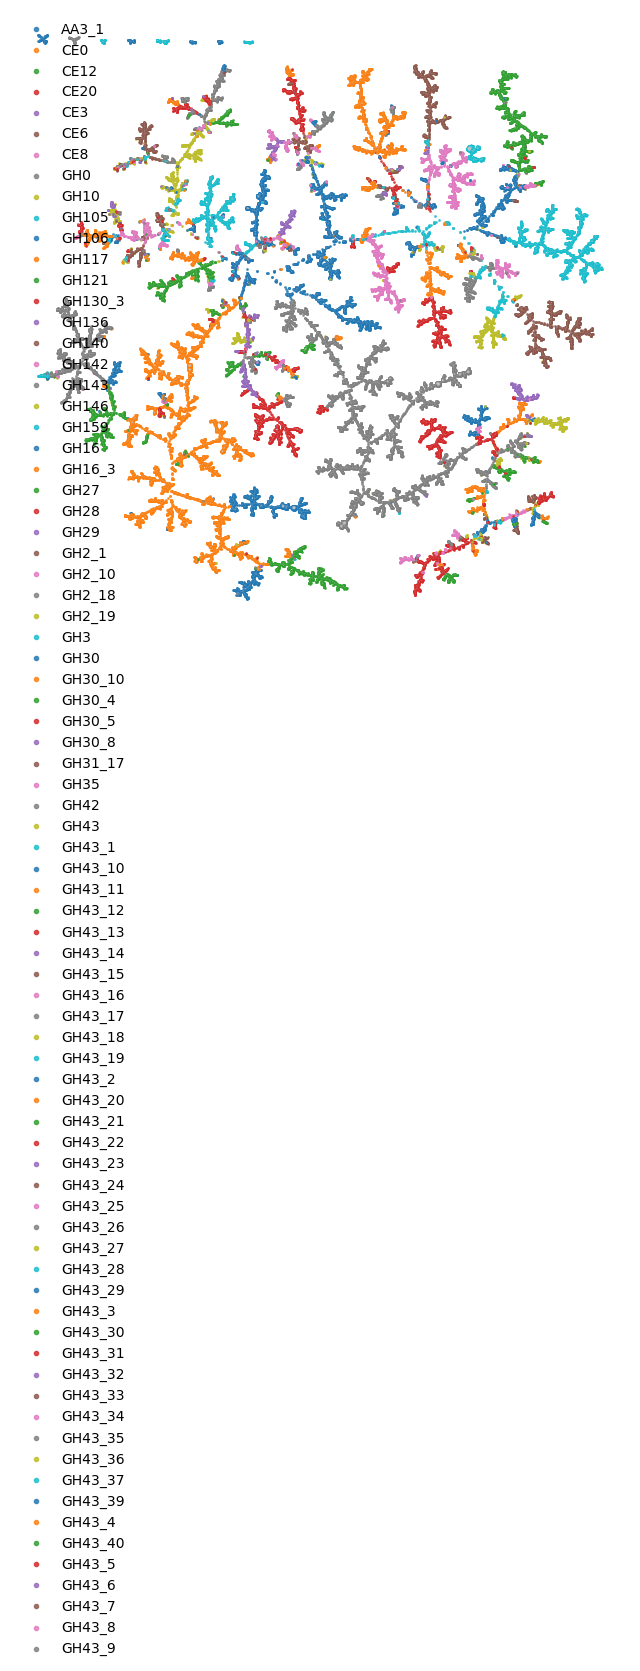

In [10]:
model.plot_static(color_by=meta["cazy_family"], color_map="tab10", point_size=1)


## Part C: Tree Exploration

We pick a sequence and calculate all the raw cosine distances to it. Next we calculate all the tmap 'hops' between the sequence and all the other sequences and plot a correlation between the two.

Query: ACL75587.1  (idx=213)
Self cosine similarity: 1.000000  (should be 1.0)


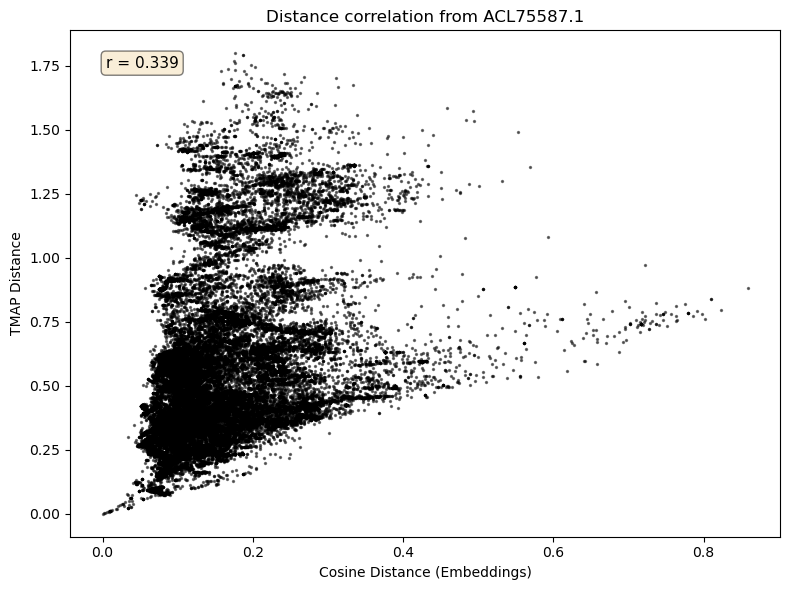

Pearson r = 0.3391


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
query_id = "ACL75587.1"  # change here to update both this cell and the Diamond cell below
hits = np.flatnonzero(ids == query_id)
if len(hits) == 0:
    raise ValueError(f"{query_id} not found in ids")
QUERY_IDX = int(hits[0])
print(f"Query: {query_id}  (idx={QUERY_IDX})")

# TMAP distances from query to all sequences
tmap_dists = model.distances_from(QUERY_IDX)

# Cosine distances — normalise first so dot product == cosine similarity
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normed = embeddings / norms
query_normed = embeddings_normed[QUERY_IDX:QUERY_IDX+1]
cosine_sims  = (query_normed @ embeddings_normed.T).flatten()
cosine_dists = 1.0 - cosine_sims

print(f"Self cosine similarity: {cosine_sims[QUERY_IDX]:.6f}  (should be 1.0)")

corr_df = pd.DataFrame({
    "tmap_distance":   tmap_dists,
    "cosine_distance": cosine_dists,
})

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(corr_df["cosine_distance"], corr_df["tmap_distance"],
           alpha=0.5, s=2, rasterized=True, color='black')
ax.set_xlabel("Cosine Distance (Embeddings)")
ax.set_ylabel("TMAP Distance")
ax.set_title(f"Distance correlation from {query_id}")

corr_coef = corr_df[["cosine_distance", "tmap_distance"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"r = {corr_coef:.3f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
print(f"Pearson r = {corr_coef:.4f}")

Next we plot the Diamond blastp sequence similarity vs the tmap hops.

Diamond hits: 33,330 / 48,078 sequences
Spearman r = 0.184   p = 1.81e-248   N = 33,004


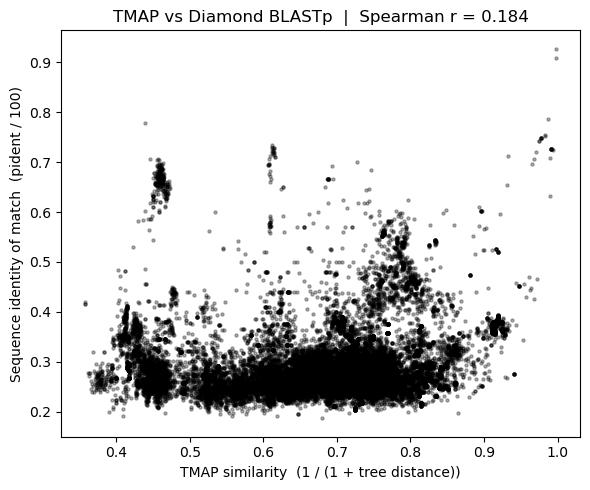

In [16]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# QUERY_IDX and tmap_dists are set in the cosine distance cell above
BLAST_THREADS = 4

id_to_seq = {rid.split("|")[0]: seq for rid, seq in zip(ids_fasta, sequences)}

with open("diamond_db.fasta", "w") as f:
    for sid in ids:
        if sid in id_to_seq:
            f.write(f">{sid}\n{id_to_seq[sid]}\n")

with open("diamond_query.fasta", "w") as f:
    f.write(f">{query_id}\n{id_to_seq[query_id]}\n")

subprocess.run(
    ["diamond", "makedb", "--in", "diamond_db.fasta", "--db", "diamond_db"],
    check=True, capture_output=True,
)

subprocess.run([
    "diamond", "blastp",
    "--query", "diamond_query.fasta", "--db", "diamond_db",
    "--outfmt", "6", "qseqid", "sseqid", "bitscore", "evalue", "pident",
    "--out", "diamond_results.tsv",
    "--evalue", "100000",
    "--max-target-seqs", "0",
    "--min-score", "0",
    "--threads", str(BLAST_THREADS),
    "--ultra-sensitive",
], check=True, capture_output=True)

blast_df = pd.read_csv("diamond_results.tsv", sep="\t",
                       names=["qseqid", "sseqid", "bitscore", "evalue", "pident"])
print(f"Diamond hits: {len(blast_df):,} / {len(ids):,} sequences")

# Similarity: pident as fraction (0–1); NaN for no-hit
id_to_pident = dict(zip(blast_df["sseqid"], blast_df["pident"]))
blast_sim = np.array([id_to_pident.get(sid, np.nan) for sid in ids]) / 100.0

# TMAP similarity: 1 / (1 + distance), maps [0, ∞) → (0, 1]
tmap_d   = np.where(np.isfinite(tmap_dists), tmap_dists, np.nan)
tmap_sim = 1.0 / (1.0 + tmap_d)

mask = np.isfinite(tmap_sim) & np.isfinite(blast_sim)
mask[QUERY_IDX] = False

r, p = spearmanr(tmap_sim[mask], blast_sim[mask])
print(f"Spearman r = {r:.3f}   p = {p:.2e}   N = {mask.sum():,}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(tmap_sim[mask], blast_sim[mask], s=5, alpha=0.3, rasterized=True, color='black')
ax.set_xlabel("TMAP similarity  (1 / (1 + tree distance))")
ax.set_ylabel("Sequence identity of match  (pident / 100)")
ax.set_title(f"TMAP vs Diamond BLASTp  |  Spearman r = {r:.3f}")
plt.tight_layout()
plt.show()

Visualize those two metrics in the tmap.

/var/folders/y9/03cy15vn41jfykwhlpv0fx300000gn/T/ipykernel_48201/352405951.py:6: UserWarning: Continuous layout 'tmap_similarity_from_query' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout("tmap_similarity_from_query",   tmap_sim.tolist(),    color="magma")
/var/folders/y9/03cy15vn41jfykwhlpv0fx300000gn/T/ipykernel_48201/352405951.py:8: UserWarning: Continuous layout 'diamond_pident_from_query' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout("diamond_pident_from_query",    blast_sim_c.tolist(), color="magma")


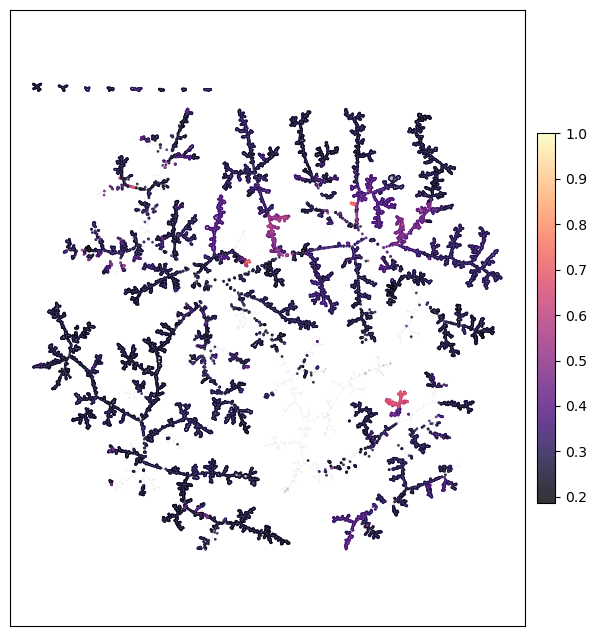

In [ ]:
tmap_d      = np.where(np.isfinite(tmap_dists), tmap_dists, np.nan)
tmap_sim    = (1.0 / (1.0 + tmap_d))           # higher = more similar
cosine_sim  = (1.0 - cosine_dists).astype(float)  # higher = more similar
blast_sim_c = blast_sim.copy()                  # pident/100, higher = more similar

viz.add_color_layout("tmap_similarity_from_query",   tmap_sim.tolist(),    color="magma")
viz.add_color_layout("cosine_similarity_from_query", cosine_sim.tolist(),  color="magma")
viz.add_color_layout("diamond_pident_from_query",    blast_sim_c.tolist(), color="magma")

viz.write_html("protein_map_GH43_cosine_with_distances.html")


meta["tmap_similarity_from_query"]   = tmap_sim
meta["cosine_similarity_from_query"] = cosine_sim
meta["diamond_pident_from_query"]    = blast_sim_c


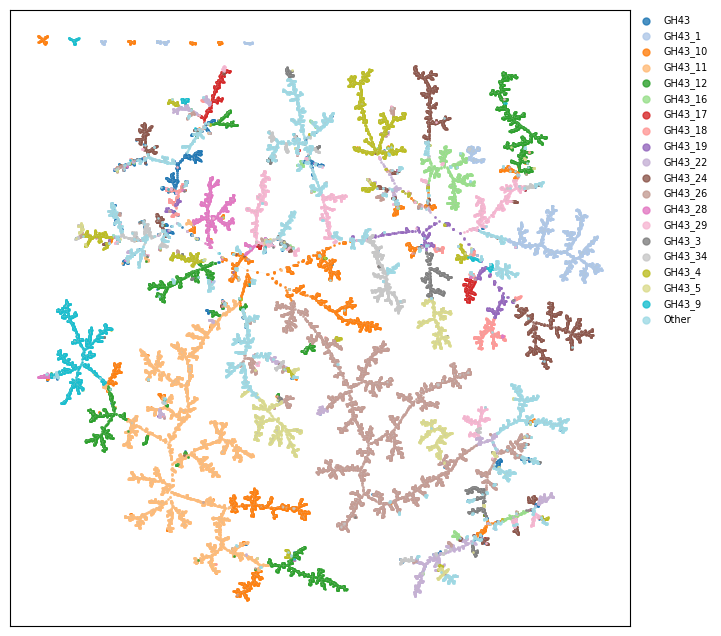

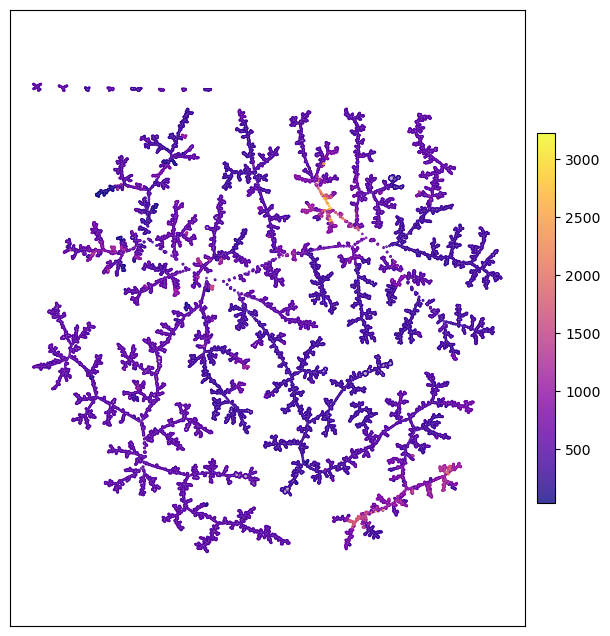

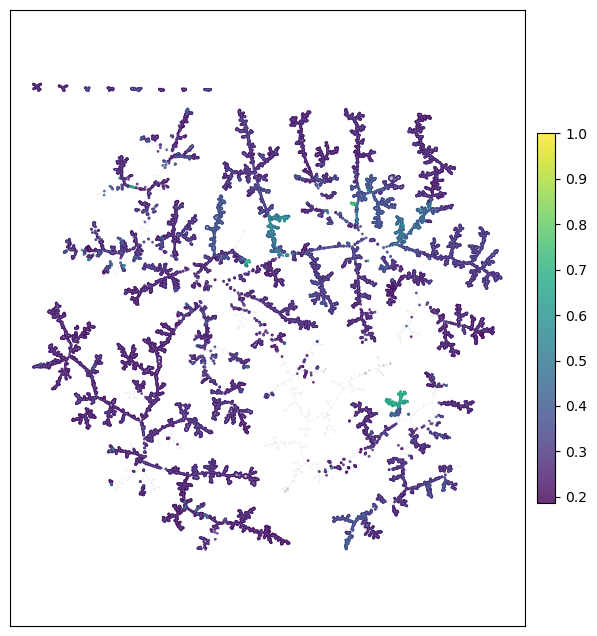

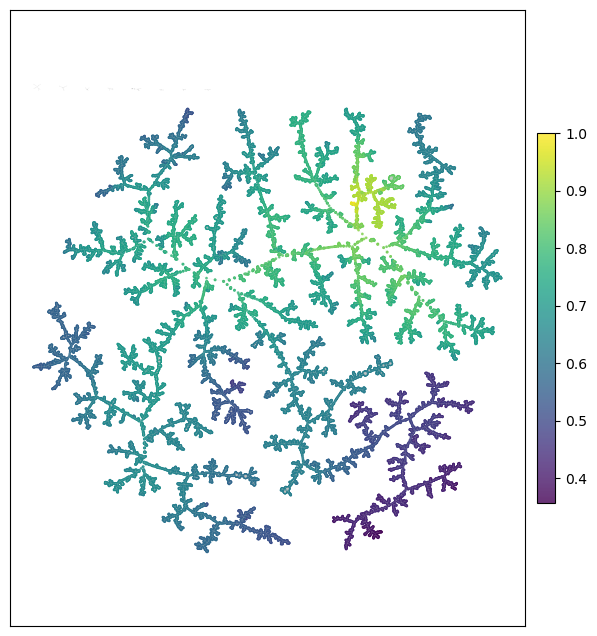

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_static_grouped(model, color_by, color_map=None, top_n=19,
                        point_size=1, savepath=None, **kwargs):
    color_by = pd.Series(color_by).reset_index(drop=True)
    is_categorical = not pd.api.types.is_numeric_dtype(color_by)

    if is_categorical:
        counts = color_by.dropna().value_counts()
        if len(counts) > top_n:
            top_cats = counts.nlargest(top_n).index
            keep = color_by.isin(top_cats) | color_by.isna()
            color_by = color_by.where(keep, "Other")          # rare -> "Other"
        color_map = color_map or "tab20"

    ax = model.plot_static(color_by=color_by, color_map=color_map,
                           point_size=point_size, **kwargs)

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
        ax.legend(markerscale=5, frameon=False, fontsize=7,
                  bbox_to_anchor=(1.0, 1.0), loc="upper left", borderaxespad=0.2)

    for spine in ax.spines.values():
        spine.set_visible(True)

    if savepath:
        ax.figure.savefig(savepath, dpi=600, bbox_inches="tight")
    return ax


# categorical — grouped into top 19 + "Other", tab20 colors, NaNs skipped
plot_static_grouped(model, meta["cazy_family"],
                    savepath="tmap_cazy_family_grouped.png")


# continuous — passes straight through to plot_static's own colorbar path
plot_static_grouped(model, meta["length"], color_map="plasma",
                    savepath="tmap_length.png")

plot_static_grouped(model, meta["diamond_pident_from_query"]x,
                    savepath="diamond_pident_from_query.png")

plot_static_grouped(model, meta["tmap_similarity_from_query"],
                    savepath="tmap_similarity_from_query.png")




plt.show()


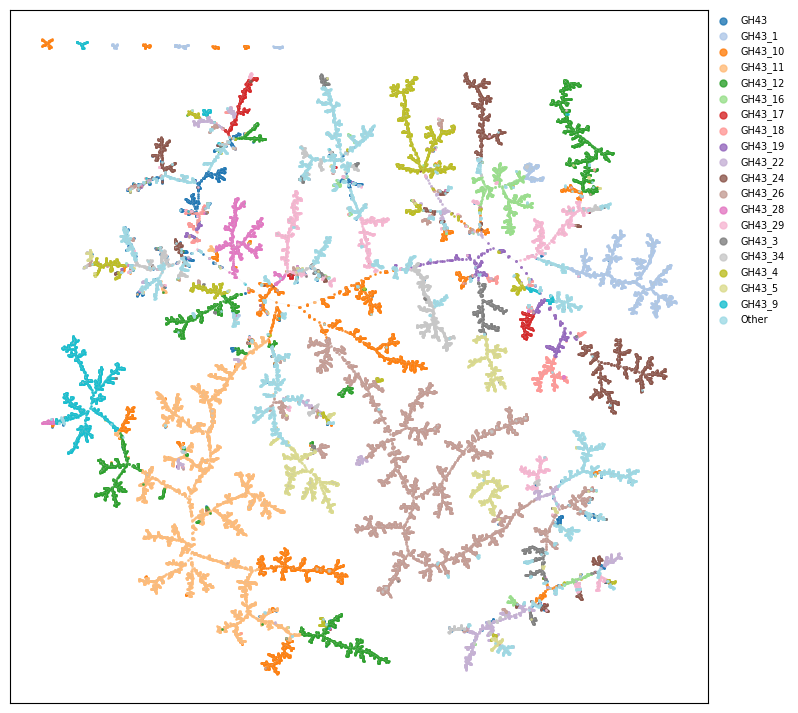

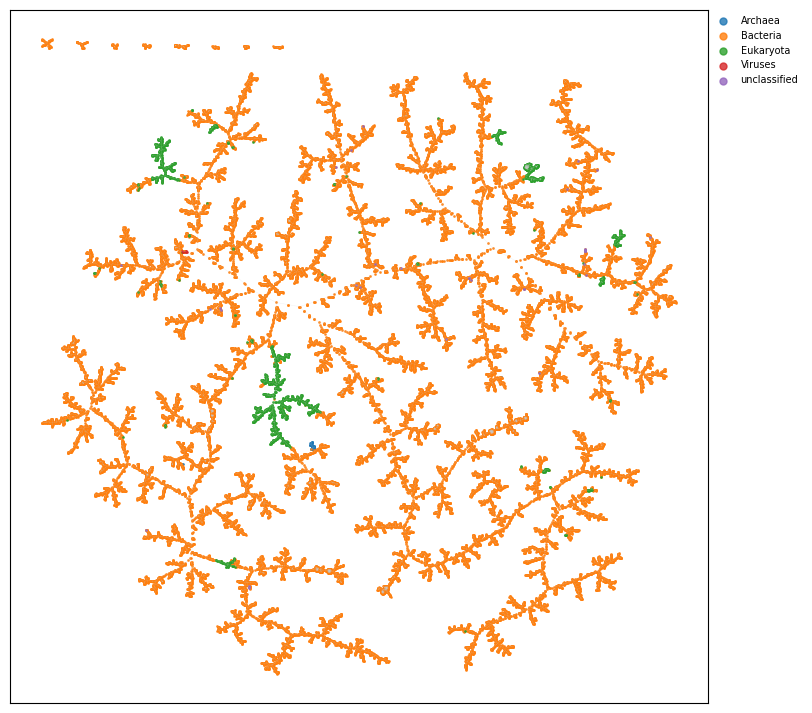

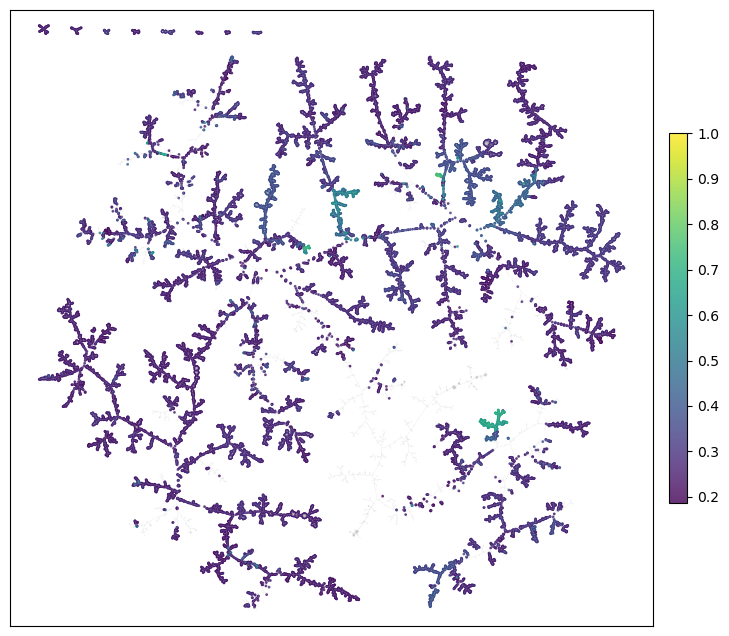

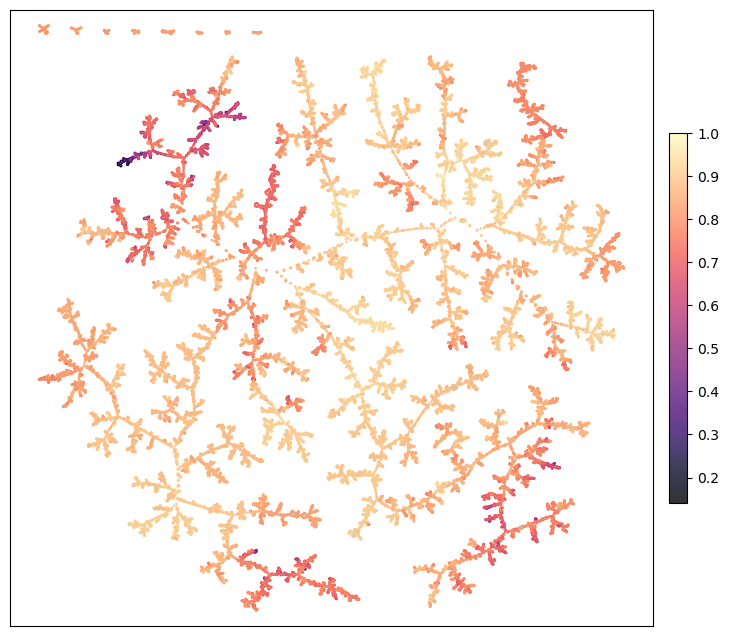

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_static_grouped(model, color_by, color_map=None, top_n=19,
                        point_size=1, savepath=None, **kwargs):
    color_by = pd.Series(color_by).reset_index(drop=True)
    is_categorical = not pd.api.types.is_numeric_dtype(color_by)

    if is_categorical:
        counts = color_by.dropna().value_counts()
        if len(counts) > top_n:
            top_cats = counts.nlargest(top_n).index
            keep = color_by.isin(top_cats) | color_by.isna()
            color_by = color_by.where(keep, "Other")          # rare -> "Other"
        color_map = color_map or "tab20"
        figsize = (9, 9)
    else:
        # continuous plots get a colorbar, which narrows the axes box and —
        # combined with set_aspect("equal", adjustable="datalim") — makes the
        # data limits expand vertically to compensate. Extra width keeps the
        # box proportions (and the visible data range) the same as categorical.
        figsize = (10, 8)

    fig, ax = plt.subplots(figsize=figsize)
    ax = model.plot_static(color_by=color_by, color_map=color_map,
                           point_size=point_size, ax=ax, **kwargs)

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
        ax.legend(markerscale=5, frameon=False, fontsize=7,
                  bbox_to_anchor=(1.0, 1.0), loc="upper left", borderaxespad=0.2)

    for spine in ax.spines.values():
        spine.set_visible(True)

    if savepath:
        ax.figure.savefig(savepath, dpi=600, bbox_inches="tight")
    return ax


# categorical — grouped into top 19 + "Other", tab20 colors, NaNs skipped
plot_static_grouped(model, meta["cazy_family"],
                    savepath="tmap_cazy_family_grouped.png")

plot_static_grouped(model, meta["domain"], color_map="tab10",
                    savepath="tmap_domain_grouped.png")

# continuous — passes straight through to plot_static's own colorbar path
plot_static_grouped(model, meta["diamond_pident_from_query"],
                    savepath="diamond_pident_from_query.png")

plot_static_grouped(model, meta["cosine_similarity_from_query"], color_map="magma",
                    savepath="cosine_similarity_from_query.png")

plt.show()


---
## Classical Methods

PCA, UMAP, and t-SNE applied to ESMC-300M embeddings, colored by taxonomic domain.
t-SNE uses 50 PCA components as input to keep runtime manageable.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Verify alignment — meta must have exactly one row per embedding
assert len(meta) == len(embeddings), (
    f"meta ({len(meta)} rows) != embeddings ({len(embeddings)} rows); "
    "a merge created duplicate rows — deduplicate meta.drop_duplicates('id') first"
)

GREY_LABELS = {"nan", "NaN", "Unknown"}

# Fill actual NaN → "nan" so every point gets an explicit label
domain_series = meta["domain"].fillna("nan").reset_index(drop=True)

unique_domains = sorted(v for v in domain_series.unique() if v not in GREY_LABELS)
_cmap = plt.cm.Set1.colors if len(unique_domains) <= 9 else plt.cm.tab20.colors
domain_color_map = {d: _cmap[i % len(_cmap)] for i, d in enumerate(unique_domains)}
for lbl in GREY_LABELS:
    domain_color_map[lbl] = "#d3d3d3"

# Grey labels drawn first so colored points render on top
_grey_present = [lbl for lbl in sorted(GREY_LABELS) if (domain_series == lbl).any()]
plot_order = _grey_present + unique_domains

print(f"Proteins: {len(domain_series)}")
print(domain_series.value_counts(dropna=False).to_string())

# PCA-50 used as t-SNE input; PCA-2 plotted directly
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(embeddings)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(embeddings)
print(f"\nPCA-2 explained variance: {pca2.explained_variance_ratio_.sum():.1%}")

Proteins: 48078
domain
Bacteria        44917
Eukaryota        2228
nan               839
Archaea            50
unclassified       36
Viruses             8

PCA-2 explained variance: 52.0%


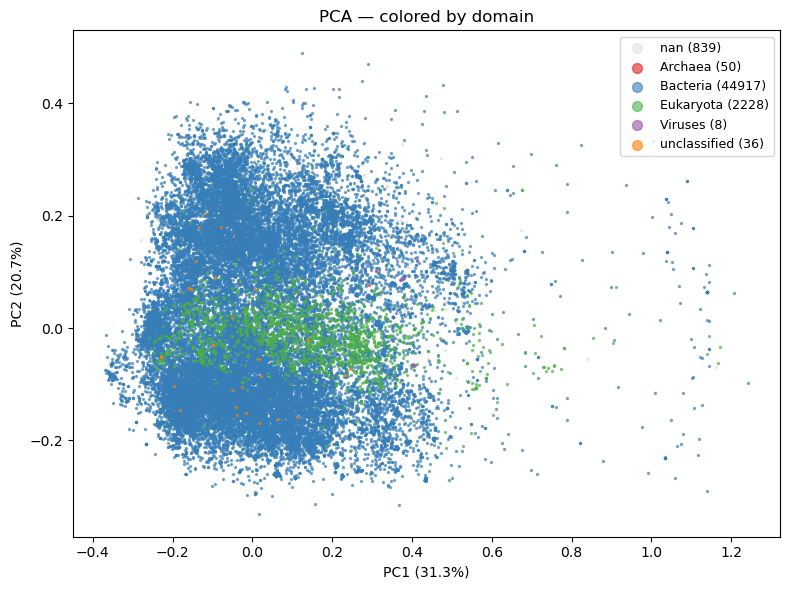

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
for d in plot_order:
    mask = (domain_series == d).values
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=[domain_color_map[d]], s=2, alpha=0.4 if d in GREY_LABELS else 0.6,
               label=f"{d} ({mask.sum()})", rasterized=True)
ax.set_title("PCA — colored by domain")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.legend(markerscale=5, framealpha=0.8, fontsize=9)
plt.tight_layout()
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


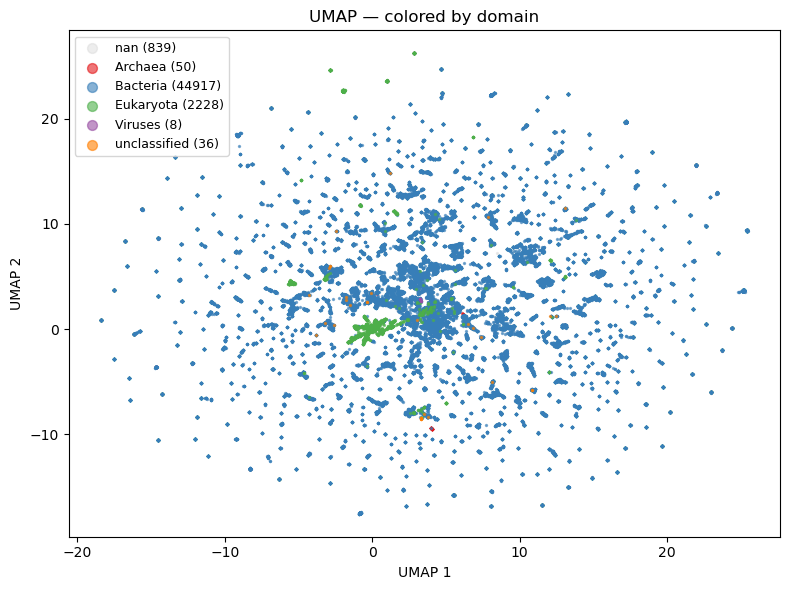

In [55]:
import umap

reducer = umap.UMAP(n_components=2, n_neighbors=20, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for d in plot_order:
    mask = (domain_series == d).values
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=[domain_color_map[d]], s=2, alpha=0.4 if d in GREY_LABELS else 0.6,
               label=f"{d} ({mask.sum()})", rasterized=True)
ax.set_title("UMAP — colored by domain")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(markerscale=5, framealpha=0.8, fontsize=9)
plt.tight_layout()
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 48078 samples in 0.001s...
[t-SNE] Computed neighbors for 48078 samples in 2.211s...
[t-SNE] Computed conditional probabilities for sample 1000 / 48078
[t-SNE] Computed conditional probabilities for sample 2000 / 48078
[t-SNE] Computed conditional probabilities for sample 3000 / 48078
[t-SNE] Computed conditional probabilities for sample 4000 / 48078
[t-SNE] Computed conditional probabilities for sample 5000 / 48078
[t-SNE] Computed conditional probabilities for sample 6000 / 48078
[t-SNE] Computed conditional probabilities for sample 7000 / 48078
[t-SNE] Computed conditional probabilities for sample 8000 / 48078
[t-SNE] Computed conditional probabilities for sample 9000 / 48078
[t-SNE] Computed conditional probabilities for sample 10000 / 48078
[t-SNE] Computed conditional probabilities for sample 11000 / 48078
[t-SNE] Computed conditional probabilities for sample 12000 / 48078
[t-SNE] Computed conditional probabilities for sam

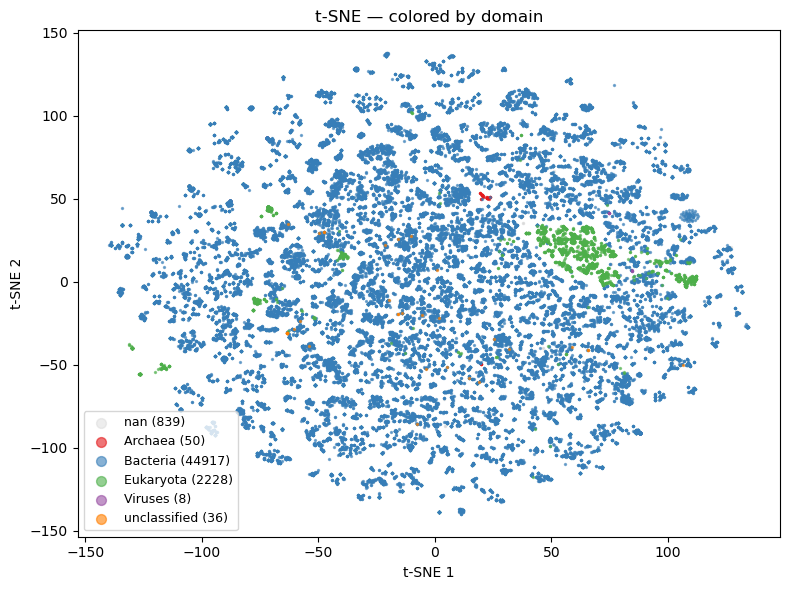

In [57]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_pca50)

fig, ax = plt.subplots(figsize=(8, 6))
for d in plot_order:
    mask = (domain_series == d).values
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[domain_color_map[d]], s=2, alpha=0.4 if d in GREY_LABELS else 0.6,
               label=f"{d} ({mask.sum()})", rasterized=True)
ax.set_title("t-SNE — colored by domain")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=5, framealpha=0.8, fontsize=9)
plt.tight_layout()
plt.show()

### 10. Tree exploration

Pick a high-confidence protein and trace pseudotime from it.

In [ ]:
# Find the protein with highest pLDDT
best = int(np.nanargmax(af_data["plddt"]))
print(f"Root: {ids[best]} (pLDDT = {af_data['plddt'][best]:.1f})")

pseudotime = model.distances_from(best)
print(f"Pseudotime range: [{pseudotime.min():.1f}, {pseudotime.max():.1f}]")

model.plot_static(color_by=pseudotime, color_map="magma", point_size=1)
